In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
import seaborn as sns
from numpy.random import laplace

## Chargeons les données adult

In [25]:
url = r"C:\Users\acer\Downloads\projet_sbd_Franck_LAGOU\adult\adult.data"
names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
         'marital-status', 'occupation', 'relationship', 'race',
         'sex', 'capital-gain', 'capital-loss', 'hours-per-week',
         'native-country','income']

adult = pd.read_csv(url, sep=",", header=None, names=names, na_values='?', engine='python', skipinitialspace=True)

adult.dropna(inplace=True)
adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# Executons les requêtes 

### Distribution ( histogramme ) sur le niveau d'éducation

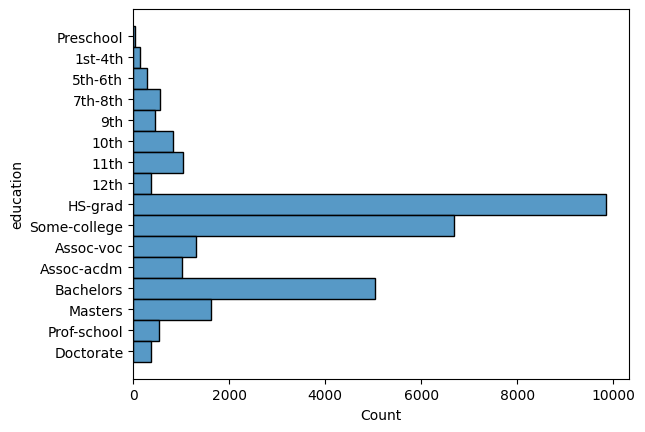

In [26]:
sns.histplot(data=adult.sort_values(by='education-num'), y='education');

# I- L' algorithme Privilet

#### Q1 :Implémentons l'algorithme de Privelet unidimensionnel décrit dans la section 4 « Privelet pour les données ordinales unidimensionnelles

In [27]:
# Instanciation de Privilet
from numpy.random import laplace

def haar_wavelet_transform(data):
    """
    Privelet first computes the Haar wavelet
        coefficients of the frequency matrix M of T.
    Applique la Haar Wavelet Transform (HWT) à une liste de données.
    Retourne les coefficients (base + internes).
    """
    data = np.array(data, dtype=float)
    n = len(data)
    coefficients = []
    
    def arbre(segment):
        # Utilisation d'une garde pour la condition d'arrêt
        taille = len(segment)
        if taille == 1:
            return segment[0]

        # Division du segment en deux parties égales
        milieu = taille // 2
        gauche, droite = segment[:milieu], segment[milieu:]

        # Calcul des moyennes (on ne le fait qu'une fois)
        m_gauche, m_droite = np.nanmean(gauche), np.nanmean(droite)
        
        # Calcul du coefficient de détail
        coeff = (m_gauche - m_droite) / 2.0
        coefficients.append(coeff)

        # Appels récursifs
        arbre(gauche)
        arbre(droite)

        return coeff
    # c0 : niveau de base moyen
    coefficient_de_base = np.nanmean(data)
    coefficients.insert(0, coefficient_de_base)
    arbre(data)
    return coefficients

In [28]:
def compute_whaar_weights(num_coeffs):
    """
    Calcule les poids WHaar des coefficients pour Privelet.
    num_coeffs doit être une puissance de 2.
    """
    if (num_coeffs & (num_coeffs - 1)) != 0:
        raise ValueError("num_coeffs doit être une puissance de 2")

    l = int(np.log2(num_coeffs))

    # Niveau 0 : poids du coefficient de base
    # Niveaux 1..l : 2^(level-1) nœuds de poids 2^(l - level + 1)
    weights = [2**l] + [
        2**(l - level + 1)
        for level in range(1, l + 1)
        for _ in range(2**(level - 1))
    ]

    return weights[:num_coeffs]

In [29]:
def add_laplace_noise(coeffs, epsilon):
    """
    Ajoute du bruit Laplacien aux coefficients Haar en fonction de WHaar.
    """
    weights = compute_whaar_weights(len(coeffs))
    lambda_ = (1 + np.log2(len(weights))) / epsilon

    return [
        c + laplace(scale=lambda_ / w)
        for c, w in zip(coeffs, weights)
    ]

In [30]:
def inverse_haar_wavelet_transform(coeffs):
    """
    Reconstitue les données à partir des coefficients Haar.
    """
    levels = int(np.log2(len(coeffs)))
    idx = 1
    reconstructed = np.array([coeffs[0]])

    for _ in range(levels):
        pairs = [(val + coeffs[i], val - coeffs[i])
                 for val, i in zip(reconstructed, range(idx, idx + len(reconstructed)))]
        idx += len(reconstructed)
        reconstructed = np.array([v for pair in pairs for v in pair])

    return reconstructed

In [31]:
def privelet_transform(data, epsilon):
    """
    Implémente le Privelet transform (1D) pour données ordinales.
    """
    noisy_coeffs = add_laplace_noise(haar_wavelet_transform(data), epsilon)
    return inverse_haar_wavelet_transform(noisy_coeffs), noisy_coeffs

# Test

In [32]:
original_data = [12, 5, 8, 3, 10, 7, 1, 6]  # longueur = 8 = 2^3
epsilon = 1.0

print("Données de base ")
print(original_data)

Données de base 
[12, 5, 8, 3, 10, 7, 1, 6]


In [33]:
coeffs = haar_wavelet_transform(original_data)
print("\n Coefficients Haar ", np.round(coeffs, 3), sep="\n")


 Coefficients Haar 
[ 6.5  0.5  1.5  3.5  2.5  2.5  1.5 -2.5]


In [34]:
poids = compute_whaar_weights(len(coeffs))
print("\n Poids ", weights, sep="\n")


 Poids 
[8, 8, 4, 4, 2, 2, 2, 2]


In [35]:
noisy_coeffs = add_laplace_noise(coeffs, epsilon)
print("\n Coefficients bruités ", np.round(noisy_coeffs, 2), sep="\n")


 Coefficients bruités 
[ 7.39 -0.1  -0.73  7.43  0.42  2.   -3.34 -1.96]


In [36]:
data_reconstructed_by_coeff = inverse_haar_wavelet_transform(noisy_coeffs)
print("\n Données  bruitées ", np.round(data_reconstructed_by_coeff, 2), sep="\n")


 Données  bruitées 
[ 6.97  6.14 10.01  6.02 11.58 18.26 -1.89  2.02]


In [37]:
perfect_reconstruction = inverse_haar_wavelet_transform(coeffs)
print("\n Reconstruction sans bruit (validation) ", np.round(perfect_reconstruction, 2), sep="\n")


 Reconstruction sans bruit (validation) 
[11.  6.  8.  3. 11.  8.  0.  5.]


#### Q2 : Testez votre code avec Privelet pour calculer la requête H1 avec ² 2 {0,01 ; 0,1 ; 1}

In [38]:
education_counts = adult['education'].value_counts().sort_index()
labels, edu_true_histogram = education_counts.index.tolist(), education_counts.values
edu_true_histogram

array([ 820, 1048,  377,  151,  288,  557,  455, 1008, 1307, 5044,  375,
       9840, 1627,   45,  542, 6678])

In [39]:
def pad_to_power_of_two(arr):
    padded = np.zeros(2**int(np.ceil(np.log2(len(arr)))))
    padded[:len(arr)] = arr
    return padded

edu_original_data = pad_to_power_of_two(edu_true_histogram)
edu_original_data

array([ 820., 1048.,  377.,  151.,  288.,  557.,  455., 1008., 1307.,
       5044.,  375., 9840., 1627.,   45.,  542., 6678.])

In [40]:
edu_epsilons = [0.01, 0.1, 1]

for edu_epsilon in edu_epsilons:
    print(f"\n{'='*40} ε = {edu_epsilon} {'='*40}")
    edu_coeffs = haar_wavelet_transform(edu_original_data)
    edu_weights = compute_whaar_weights(len(edu_coeffs))
    edu_noisy_coeffs = add_laplace_noise(edu_coeffs, edu_epsilon)
    edu_reconstructed = inverse_haar_wavelet_transform(edu_noisy_coeffs)
    print("Histogramme reconstruit bruité :", np.round(edu_reconstructed, 2), sep="\n")


======================================== ε = 0.01 ========================================
Histogramme reconstruit bruité :
[ -432.54   700.71  3231.14 -1339.76  -772.11  1345.36 -1542.9   2854.9
 -1657.65  8288.4   2035.82  4963.29  3809.48  1329.46  -697.57  6072.54]

======================================== ε = 0.1 ========================================
Histogramme reconstruit bruité :
[  228.32   690.49  1698.15  -275.96  -337.56  1675.86 -1337.64  2322.47
 -1354.44  8081.92  2269.1   5015.67  3519.19  1979.84  -113.42  5956.19]

======================================== ε = 1 ========================================
Histogramme reconstruit bruité :
[  204.99   756.83  1667.32  -236.32  -272.42  1658.17 -1401.49  2325.92
 -1372.87  8101.32  2283.86  5054.15  3501.35  1928.1    -85.52  6047.97]


#### histogramme d'origine et de l'histogramme bruité

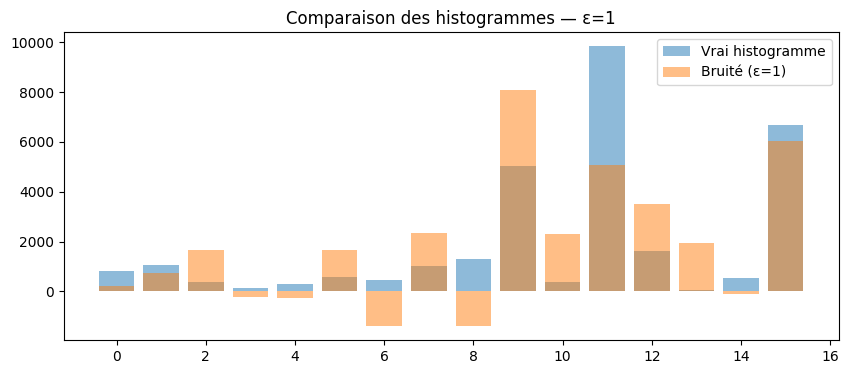

In [41]:
plt.figure(figsize=(10, 4))
plt.bar(range(len(edu_original_data)), edu_original_data, alpha=0.5, label='Vrai histogramme')
plt.bar(range(len(edu_reconstructed)), edu_reconstructed, alpha=0.5, label=f'Bruité (ε={edu_epsilon})')
plt.title(f'Comparaison des histogrammes — ε={edu_epsilon}')
plt.legend()
plt.show()

##  II- Experimentation 

In [42]:
edu_true_histogram

array([ 820, 1048,  377,  151,  288,  557,  455, 1008, 1307, 5044,  375,
       9840, 1627,   45,  542, 6678])

In [43]:
from scipy.stats import wasserstein_distance

compute_wasserstein = lambda original_hist, perturbed_hist: wasserstein_distance(original_hist, perturbed_hist)

In [44]:
def experiment(edu_true_histogram, q3_epsilon_values, num_runs=20):
    wasserstein_distances = {eps: [] for eps in q3_epsilon_values}
    coefficients = haar_wavelet_transform(edu_true_histogram)

    for eps in q3_epsilon_values:
        print(f"\n=== ε = {eps} ===")

        wasserstein_distances[eps] = [
            compute_wasserstein(edu_true_histogram, inverse_haar_wavelet_transform(add_laplace_noise(coefficients, eps)))
            for _ in range(num_runs)
        ]

        distances = wasserstein_distances[eps]
        print(f"Moyenne : {np.mean(distances):.4f} | Min : {np.min(distances):.4f} | Max : {np.max(distances):.4f}")

    return wasserstein_distances

In [45]:
def plot_wasserstein_distances(wasserstein_distances, q3_epsilon_values):
    stats = {
        'Moyenne': (np.mean, 'x', '-',  'b'),
        'Minimum': (np.min,  '*', '--', 'r'),
        'Maximum': (np.max,  'o', ':',  'g'),
    }

    plt.figure(figsize=(10, 6))
    for label, (fn, marker, ls, color) in stats.items():
        plt.plot(q3_epsilon_values, [fn(wasserstein_distances[e]) for e in q3_epsilon_values],
                 label=label, marker=marker, linestyle=ls, color=color)

    plt.xlabel('Valeur de ε')
    plt.ylabel('Distance de Wasserstein')
    plt.title('Évaluation de Privelet : Distance de Wasserstein selon ε')
    plt.legend()
    plt.xscale('log')
    plt.grid(True)
    plt.show()

In [47]:

# Histogramme original (edu_true_histogram) à tester
edu_true_histogram = np.array([820, 1048, 377, 151, 288, 557, 455, 1008, 1307, 5044, 375, 9840, 1627, 45, 542, 6678])

# Valeurs de epsilon à tester
q3_epsilon_values = [0.01, 0.1, 1, 10]

# Réaliser l'expérience
wasserstein_distances = experiment(edu_true_histogram, q3_epsilon_values)



=== ε = 0.01 ===
Moyenne : 924.8407 | Min : 753.4687 | Max : 1053.0743

=== ε = 0.1 ===
Moyenne : 906.4032 | Min : 890.1240 | Max : 933.1648

=== ε = 1 ===
Moyenne : 905.1162 | Min : 902.7816 | Max : 907.3333

=== ε = 10 ===
Moyenne : 904.7936 | Min : 904.6123 | Max : 904.9999


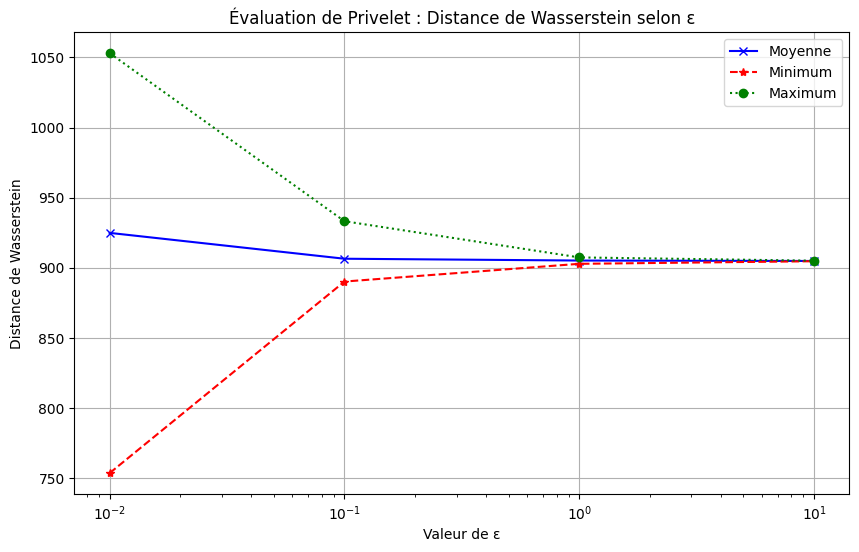

In [48]:
plot_wasserstein_distances(wasserstein_distances, q3_epsilon_values)

## Analyse du graphe

**Petits ε (0.01, 0.1)** → distance de Wasserstein élevée : le bruit important déforme fortement l'histogramme, garantissant une meilleure confidentialité au détriment de la précision.

**Grands ε (1, 10)** → distance de Wasserstein faible : moins de bruit, donc l'histogramme reconstruit est plus fidèle à l'original, mais la protection de la vie privée est réduite.

> Plus ε est grand, moins il y a de bruit → meilleure précision mais confidentialité plus faible, et inversement.

Les courbes moyenne, minimum et maximum décroissent toutes lorsque ε augmente, confirmant ce compromis **confidentialité / utilité**.

La distance de Wasserstein décroît avec ε, illustrant le compromis fondamental de la confidentialité différentielle : **petit ε → plus de bruit → meilleure confidentialité mais moins de précision**, et inversement.

## Conclusion

L'expérience montre que la distance de Wasserstein varie significativement selon ε : faible pour les grands ε (données reconstruites proches de l'original) et élevée pour les petits ε (forte perturbation due au bruit). Ce résultat illustre le compromis fondamental de la confidentialité différentielle — précision vs confidentialité — cohérent avec ses principes théoriques.